In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

In [ ]:
data_dir = '/content/drive/MyDrive/quora_data'
train_df = pd.read_csv(f'{data_dir}/train.csv')
test_df = pd.read_csv(f'{data_dir}/test.csv')
sub_df = pd.read_csv(f'{data_dir}/sample_submission.csv')

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission:", sub_df.shape)

Train shape: (1306122, 3)
Test shape: (375806, 2)
Sample submission: (375806, 2)


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/quora_data'))

['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
data_dir = '/content/drive/MyDrive/quora_data'
train_fname = f'{data_dir}/train.csv'
test_fname = f'{data_dir}/test.csv'
sub_fname = f'{data_dir}/sample_submission.csv'

In [ ]:
raw_df = pd.read_csv(train_fname)
test_df = pd.read_csv(test_fname)
sub_df = pd.read_csv(sub_fname)

In [ ]:
raw_df

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0
...,...,...,...
1306117,ffffcc4e2331aaf1e41e,What other technical skills do you need as a c...,0
1306118,ffffd431801e5a2f4861,Does MS in ECE have good job prospects in USA ...,0
1306119,ffffd48fb36b63db010c,Is foam insulation toxic?,0
1306120,ffffec519fa37cf60c78,How can one start a research project based on ...,0


In [ ]:
raw_df.sample(10)

,qid,question_text,target
1278455,fa8d57a41009b86440b2,What is the best microcontroller to record EMG...,0
950891,ba54f3c0e959e76b2b17,Reset your MacBook Pro?,0
757537,9469c1cd55f99caff9ed,Is it true that another Oumuamua has just been...,0
567890,6f464f58f624ac482a3d,What's gonna happen to my money in the stocks ...,0
282012,3733f149cc4cdb42cfbf,What is the best way to indulge yourself in st...,0
1211635,ed7b24f72d31bb531a76,I keep zoning out. what should I do?,0
185858,245a7d20ce3747ddce6c,Can a single punch break human ribs?,0
534121,689a00bd6066dc7bc63c,Which is the best JEE main coaching centre in ...,0
511809,643b69c187933895ff7f,Describe the ways in which the Buddha to sprea...,0
834564,a38b6c3439d2650a443e,Does being beautiful a mandatory requirement f...,0


In [ ]:
test_df

,qid,question_text
0,0000163e3ea7c7a74cd7,Why do so many women become so rude and arroga...
1,00002bd4fb5d505b9161,When should I apply for RV college of engineer...
2,00007756b4a147d2b0b3,What is it really like to be a nurse practitio...
3,000086e4b7e1c7146103,Who are entrepreneurs?
4,0000c4c3fbe8785a3090,Is education really making good people nowadays?
...,...,...
375801,ffff7fa746bd6d6197a9,How many countries listed in gold import in in...
375802,ffffa1be31c43046ab6b,Is there an alternative to dresses on formal p...
375803,ffffae173b6ca6bfa563,Where I can find best friendship quotes in Tel...
375804,ffffb1f7f1a008620287,What are the causes of refraction of light?


In [ ]:
sub_df

,qid,prediction
0,0000163e3ea7c7a74cd7,0
1,00002bd4fb5d505b9161,0
2,00007756b4a147d2b0b3,0
3,000086e4b7e1c7146103,0
4,0000c4c3fbe8785a3090,0
...,...,...
375801,ffff7fa746bd6d6197a9,0
375802,ffffa1be31c43046ab6b,0
375803,ffffae173b6ca6bfa563,0
375804,ffffb1f7f1a008620287,0


In [ ]:
SAMPLE_SIZE = 100_000
sample_df = raw_df.sample(100_000)

In [ ]:
sample_df

,qid,question_text,target
309727,3cab5f8550a65f1e36fb,How does your gender affect your daily life?,0
39491,07bab41cfeda2562fb40,What British cultures are better preserved in ...,0
1158765,e30c89a64775b929106b,My mother hits my brother and it's normal in o...,0
928704,b6016a935ee2c74c4050,Why is my chiseled jawline getting fatter? And...,0
772463,9753549f34f41d4a5ad4,Which memorization technique works best for yo...,0
...,...,...,...
262143,33502fca0846a0bab8bb,"If there are ""white knight narcissists"", are t...",1
442151,56a5c540c1919071b9ec,"Which should I choose, IT at BVP (Delhi, IPU) ...",0
850711,a6b0b3055e819092d35c,Where will the new campus for Pt.Jawaharlal Ne...,0
976290,bf46711e79b412fc2dac,Is deep learning still the most active area of...,0


In [ ]:
sample_df.target.value_counts(normalize=True)

,proportion
target,
0,0.93894
1,0.06106


Prepare Data for Training:
 * Convert text to TF-IDF vectors
 * Convert vectors to PyTorch tensors
 * Create PyTorch Data Loaders

Convert to TF-IDF Vectors

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
stemmer = SnowballStemmer(language='english')

In [ ]:
english_stopwords = stopwords.words('english')

In [ ]:
", ".join(english_stopwords)

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [ ]:
def tokenize(text):
  return [stemmer.stem(token) for token in word_tokenize(text)]

In [ ]:
vectorizer = TfidfVectorizer(tokenizer = tokenize, stop_words=english_stopwords, max_features=1000)

In [ ]:
sample_df.question_text

,question_text
309727,How does your gender affect your daily life?
39491,What British cultures are better preserved in ...
1158765,My mother hits my brother and it's normal in o...
928704,Why is my chiseled jawline getting fatter? And...
772463,Which memorization technique works best for yo...
...,...
262143,"If there are ""white knight narcissists"", are t..."
442151,"Which should I choose, IT at BVP (Delhi, IPU) ..."
850711,Where will the new campus for Pt.Jawaharlal Ne...
976290,Is deep learning still the most active area of...


In [ ]:
vectorizer.fit(sample_df.question_text)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


TfidfVectorizer(max_features=1000,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7b615525d260>)

In [ ]:
vectorizer.get_feature_names_out()[:100]

array(['!', '$', '%', '&', "'", "''", "'m", "'s", '(', ')', ',', '-', '.',
       '1', '10', '100', '12', '12th', '15', '2', '20', '2017', '2018',
       '3', '4', '5', '6', '7', '8', ':', '?', '[', ']', '``', 'abl',
       'abroad', 'abus', 'accept', 'access', 'accomplish', 'accord',
       'account', 'achiev', 'acid', 'act', 'action', 'activ', 'actor',
       'actual', 'ad', 'add', 'address', 'admiss', 'adult', 'advanc',
       'advantag', 'advic', 'affect', 'africa', 'african', 'age', 'air',
       'allow', 'alreadi', 'also', 'altern', 'alway', 'amazon', 'america',
       'american', 'among', 'amount', 'android', 'ani', 'anim', 'anoth',
       'answer', 'anyon', 'anyth', 'apart', 'app', 'appear', 'appl',
       'appli', 'applic', 'arab', 'area', 'armi', 'around', 'art',
       'asian', 'ask', 'atheist', 'attack', 'attract', 'australia',
       'author', 'avail', 'averag', 'avoid'], dtype=object)

Transform the questions into vectors

In [ ]:
inputs = vectorizer.transform(sample_df.question_text)

In [ ]:
inputs.shape

(100000, 1000)

In [ ]:
inputs

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 547620 stored elements and shape (100000, 1000)>

In [ ]:
inputs[0].toarray()[:50]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.08706121, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.552673  , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [ ]:
test_inputs = vectorizer.transform(test_df.question_text)

In [ ]:
test_inputs.shape

(375806, 1000)

Split the Training and Validation Set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
targets = sample_df.target

In [ ]:
train_inputs, val_inputs, train_targets, val_targets = train_test_split(inputs, targets, test_size = 0.3)

In [ ]:
train_inputs.shape

(70000, 1000)

In [ ]:
val_inputs.shape

(30000, 1000)

In [ ]:
train_targets

,target
415818,0
1064434,0
116639,0
758371,0
890543,1
...,...
59789,0
601917,0
578119,0
1171186,0


In [ ]:
val_targets

,target
1058406,0
1071623,0
152885,0
1046484,0
1275687,0
...,...
607633,0
595592,0
592818,1
1029096,0


Convert to PyTorch Tensors

In [ ]:
import torch

In [ ]:
train_input_tensors = torch.tensor(train_inputs.toarray()).float()
val_input_tensors = torch.tensor(val_inputs.toarray()).float()

In [ ]:
train_input_tensors.shape

torch.Size([70000, 1000])

In [ ]:
val_input_tensors.shape

torch.Size([30000, 1000])

In [ ]:
type(train_targets)

pandas.core.series.Series

In [ ]:
train_target_tensors = torch.tensor(train_targets.values).float()
val_target_tensors = torch.tensor(val_targets.values).float()

In [ ]:
test_input_tensors = torch.tensor(test_inputs.toarray()).float()

Create PyTorch Data Loaders

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_ds = TensorDataset(train_input_tensors, train_target_tensors)
val_ds = TensorDataset(val_input_tensors, val_target_tensors)
test_ds = TensorDataset(test_input_tensors)

In [ ]:
BATCH_SIZE = 128

In [ ]:
train_dl = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size = BATCH_SIZE)
test_dl = DataLoader(test_ds, batch_size = BATCH_SIZE)

In [ ]:
for batch in train_dl:
  batch_inputs = batch[0]
  batch_targets = batch[1]
  print('batch_inputs.shape', batch_inputs.shape)
  print('batch_targets.shape', batch_targets.shape)
  break

batch_inputs.shape torch.Size([128, 1000])
batch_targets.shape torch.Size([128])


In [ ]:
len(train_dl)

547

In [ ]:
547*128

70016

Train Deep Learning Model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class QuoraNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(1000, 512)
    self.layer2 = nn.Linear(512, 256)
    self.layer3 = nn.Linear(256, 128)
    self.layer4 = nn.Linear(128, 1)
    pass

  def forward(self, inputs):
    out = self.layer1(inputs)
    out = F.relu(out)
    out = self.layer2(out)
    out = F.relu(out)
    out = self.layer3(out)
    out = F.relu(out)
    out = self.layer4(out)
    return out

In [ ]:
model = QuoraNet()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
for batch in train_dl:
  bi, bt = batch
  print('inputs.shape', bi.shape)
  print('targets.shape', bt.shape)

  bo = model(bi)
  print('bo.shape', bo.shape)

  # Convert outputs to probabilities
  probs = torch.sigmoid(bo[:, 0])
  print('probs', probs[:10])

  #Convert probs to predictions
  preds = (probs > 0.5).int()
  print('preds', preds[:10])
  print('targets', bt[:10])

  #Check metrics
  print('accuracy', accuracy_score(bt, preds))
  print('f1_score', f1_score(bt, preds))

  #Loss
  print('loss', F.binary_cross_entropy(preds.float(), bt))

  break

inputs.shape torch.Size([128, 1000])
targets.shape torch.Size([128])
bo.shape torch.Size([128, 1])
probs tensor([0.4882, 0.4881, 0.4875, 0.4877, 0.4872, 0.4877, 0.4883, 0.4873, 0.4880,
        0.4879], grad_fn=<SliceBackward0>)
preds tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32)
targets tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
accuracy 0.9296875
f1_score 0.0
loss tensor(7.0312)


In [ ]:
bi[:10]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
bt[:10]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
bo[:10]

tensor([[-0.0474],
        [-0.0476],
        [-0.0499],
        [-0.0491],
        [-0.0514],
        [-0.0492],
        [-0.0468],
        [-0.0507],
        [-0.0478],
        [-0.0484]], grad_fn=<SliceBackward0>)

In [ ]:
# Evaluate model performance
def evaluate(model, dl):
  losses, accs, f1s = [], [], []
  # Loop over batches
  for batch in dl:
    #Get inputs through model
    inputs, targets = batch

    # Pass inputs through model
    outputs = model(inputs)

    # Convert to probabilities
    probs = torch.sigmoid(outputs[:, 0])

    # Compute loss
    loss = F.binary_cross_entropy(probs, targets, weight=torch.tensor(20))

    # Compute preds
    preds = (probs > 0.5).int()

    # Compute accuracy
    acc = accuracy_score(targets, preds)

    # Compute f1 score
    f1 = f1_score(targets, preds)

    losses.append(loss.item())
    accs.append(acc)
    f1s.append(f1)

  return (torch.mean(torch.tensor(losses)).item(),
          torch.mean(torch.tensor(accs)).item(),
          torch.mean(torch.tensor(f1s)).item())

In [ ]:
evaluate(model, train_dl)

(13.435444831848145, 0.9393077492713928, 0.0)

In [ ]:
evaluate(model, val_dl)

(13.436492919921875, 0.9381759166717529, 0.0)

In [ ]:
# Train the model batch by batch
def fit(epochs, lr, model, train_dl, val_dl ):
  history = []
  optimizer = torch.optim.Adam(model.parameters(), lr, weight_decay=1e-5)

  for epoch in range(epochs):
    #Training phase
    for batch in train_dl:
      #Get inputs and targets
      inputs, targets = batch

      #GEt model outputs
      outputs = model(inputs)

      #Get probabilities
      probs = torch.sigmoid(outputs[:, 0])

      #Compute loss
      loss = F.binary_cross_entropy(probs, targets, weight=torch.tensor(20))

      #Perform the optimization
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

   # Evaluation phase
    loss, acc, f1 = evaluate(model, val_dl)
    print('Epoch {}; Loss: {:.4f}; Accuracy: {:.4f}; F1 Score: {:.4f}'.format(
         epoch+1, loss, acc, f1))
    history.append([loss, acc, f1])
  return history

In [ ]:
model = QuoraNet()

In [ ]:
history = []

In [ ]:
history.append(evaluate(model, train_dl))

In [ ]:
history

[(13.49690055847168, 0.9393138885498047, 0.0)]

In [ ]:
history += fit(5, 0.0001, model, train_dl, val_dl)

Epoch 1; Loss: 3.4355; Accuracy: 0.9382; F1 Score: 0.0000
Epoch 2; Loss: 3.1817; Accuracy: 0.9391; F1 Score: 0.0424
Epoch 3; Loss: 3.1561; Accuracy: 0.9445; F1 Score: 0.3414
Epoch 4; Loss: 3.1459; Accuracy: 0.9441; F1 Score: 0.3916
Epoch 5; Loss: 3.1560; Accuracy: 0.9448; F1 Score: 0.4149


In [ ]:
history

[(13.49690055847168, 0.9393138885498047, 0.0),
 [3.435450553894043, 0.9381759166717529, 0.0],
 [3.1816811561584473, 0.9390735626220703, 0.04238380491733551],
 [3.1561107635498047, 0.9444591999053955, 0.3413518965244293],
 [3.1459250450134277, 0.9440934658050537, 0.39158645272254944],
 [3.1559581756591797, 0.9448248744010925, 0.4149298071861267]]

In [ ]:
losses = [item[0] for item in history]
accs = [item[1] for item in history]
f1s = [item[2] for item in history]

In [ ]:
import matplotlib.pyplot as plt

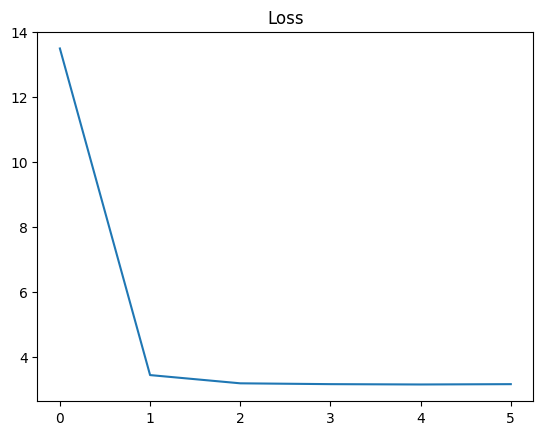

In [ ]:
plt.title('Loss')
plt.plot(losses)

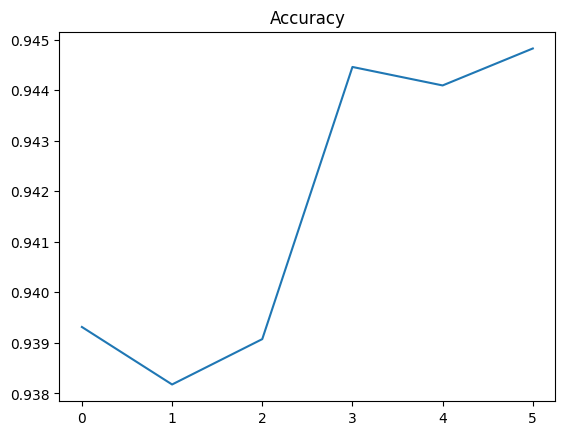

In [ ]:
plt.title('Accuracy')
plt.plot(accs)

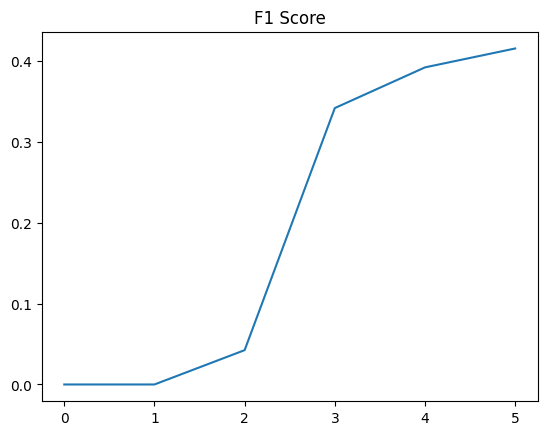

In [ ]:
plt.title('F1 Score')
plt.plot(f1s)

In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


Make predictions on example data

In [ ]:
small_df = raw_df.sample(20)

In [ ]:
small_df

,qid,question_text,target
929911,b63d6fa41f66eb027fe3,Did you ever wish you were popular?,0
375774,49a9d4e62b23b56b4219,How can I prepare ricotta gnudi?,0
954232,baf997c8981372d48d73,Are there more “beasts in some people” example...,1
1165614,e468e7a399372f4db4f9,How are the auditions of a young kid like?,0
178782,22efc00241480870bfa7,I read everywhere that I must be happy alone a...,0
1199330,eb0e805dc30c47e925d3,During my school days I carved the initials of...,0
111443,15cfbc0798f2177b7b2c,What is the next number after 58921?,0
219111,2adcf6b0abb572f38250,Which certificate course is preferred with MBA...,0
983426,c0ac53a401afb70aebd5,What qualifications and education do I need to...,0
479837,5df79322901051112a31,Is there anyone who can tell me about the best...,0


In [ ]:
def predict_df(df):
  inputs = vectorizer.transform(df.question_text)
  inputs_tensors = torch.tensor(inputs.toarray()).float()
  outputs = model(inputs_tensors)
  probs = torch.sigmoid(outputs[:, 0])
  preds = (probs > 0.5).int()
  return preds

In [ ]:
small_df.target.values


array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
predict_df(small_df)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       dtype=torch.int32)

In [ ]:
small_df.question_text.values

array(['Did you ever wish you were popular?',
       'How can I prepare ricotta gnudi?',
       'Are there more “beasts in some people” example than ethnic cleansing Ukrainians in Polish Volyn?',
       'How are the auditions of a young kid like?',
       'I read everywhere that I must be happy alone and not ask others to make me happy. But what should I do if my happiness is hindered precisely by a lack of social contact?',
       "During my school days I carved the initials of my name that's 'V' on my arm the mark still exists.Will this pose as a criteria for rejection in SSB?",
       'What is the next number after 58921?',
       'Which certificate course is preferred with MBA finance?',
       'What qualifications and education do I need to work at a US Embassy?',
       'Is there anyone who can tell me about the best colleges in Bangalore for BBA in airport management?',
       'Can a billionaire choose to not have a cell phone?',
       'Does first time sex hurt to girls who fre

In [ ]:
def predict_text(text):
  df = pd.DataFrame({'question_text': [text]})
  inputs = vectorizer.transform(df.question_text)
  inputs_tensors = torch.tensor(inputs.toarray()).float()
  outputs = model(inputs_tensors)
  probs = torch.sigmoid(outputs[:, 0])
  preds = (probs > 0.5).int()
  return preds

In [ ]:
predict_text("What is the function of a plasma cell?")

tensor([0], dtype=torch.int32)

In [ ]:
predict_text("Why can't liberals realize that they're stupid?")

tensor([1], dtype=torch.int32)

Generate Predictions for Test Set

In [ ]:
test_inputs

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2056559 stored elements and shape (375806, 1000)>

In [ ]:
import numpy as np
def make_preds(dl):
  all_preds = []
  for batch in dl:
    inputs = batch[0]
    outputs = model(inputs)
    probs = torch.sigmoid(outputs[:, 0])
    preds = (probs > 0.5).int()
    all_preds.append(preds.detach().numpy())

  return np.concatenate(all_preds)

In [ ]:
for batch in test_dl:
  print(batch[0][0])
  break

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0705, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
test_preds = make_preds(test_dl)

In [ ]:
len(test_preds)

375806

In [ ]:
test_preds

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
sub_df

,qid,prediction
0,0000163e3ea7c7a74cd7,0
1,00002bd4fb5d505b9161,0
2,00007756b4a147d2b0b3,0
3,000086e4b7e1c7146103,0
4,0000c4c3fbe8785a3090,0
...,...,...
375801,ffff7fa746bd6d6197a9,0
375802,ffffa1be31c43046ab6b,0
375803,ffffae173b6ca6bfa563,0
375804,ffffb1f7f1a008620287,0


In [ ]:
sub_df['prediction'] = test_preds

In [ ]:
pd.Series(test_preds).value_counts()

,count
0,362228
1,13578


In [ ]:
sub_df.prediction.value_counts()

,count
prediction,
0,362228
1,13578


In [ ]:
sub_df.to_csv('submission.csv', index=False)

In [ ]:
import pandas as pd

df = pd.read_csv('submission.csv')
print("Submission shape:", df.shape)
print("Columns:", df.columns)
print(df.head())
print(df['prediction'].value_counts())

Submission shape: (375806, 2)
Columns: Index(['qid', 'prediction'], dtype='object')
                    qid  prediction
0  0000163e3ea7c7a74cd7           0
1  00002bd4fb5d505b9161           0
2  00007756b4a147d2b0b3           0
3  000086e4b7e1c7146103           0
4  0000c4c3fbe8785a3090           0
prediction
0    362228
1     13578
Name: count, dtype: int64


In [ ]:
vectorizer.fit(sample_df.question_text)